# Methodology — Figures

Visualizations for the methodology chapter of the dissertation (sections 7-13).
Each figure is saved as a PNG in the `dissertation/figures/` folder.

| # | Figure | Section | File |
|---|------|---------|------|
| 1 | Target distribution (raw vs log) | 7 | fig01_target_distribution.png |
| 2 | QLIKE vs MSE loss function | 12 | fig02_qlike_vs_mse.png |
| 3 | Train/Val/Test temporal split | 11 | fig03_train_val_test_split.png |
| 4 | Purged k-fold CV scheme | 11 | fig04_purged_kfold.png |
| 5 | FNN architecture | 9 | fig05_fnn_architecture.png |
| 6 | LSTM sliding window + architecture | 10 | fig06_lstm_architecture.png |

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
})

DATA = Path("../data/processed")
SPLITS = DATA / "splits"
FIG_DIR = Path("../dissertation/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

train = pl.read_parquet(SPLITS / "train.parquet")
val = pl.read_parquet(SPLITS / "val.parquet")
test = pl.read_parquet(SPLITS / "test.parquet")
print(f"Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}")

Train: 132,680  Val: 19,402  Test: 36,924


## 1. Target distribution: raw vs log-transformed (Section 7)
The raw rv_21d_forward skewness is 5.64, dropping to 0.42 after the log transform. This motivates using LogHAR and log-space modeling.

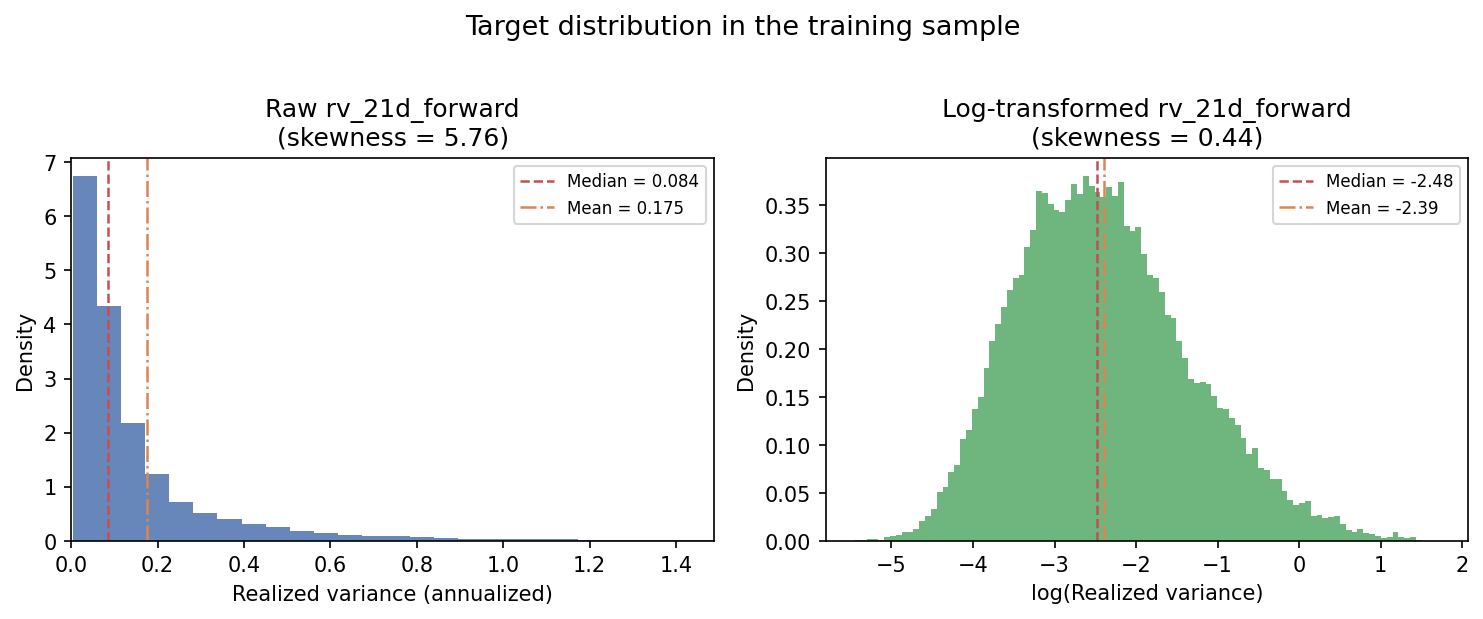

In [2]:
from scipy import stats as sp_stats

raw = train["rv_21d_forward"].to_numpy()
log = np.log(raw)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Raw
ax = axes[0]
ax.hist(raw, bins=100, color="#4C72B0", edgecolor="none", alpha=0.85, density=True)
skew_raw = sp_stats.skew(raw)
ax.set_title(f"Raw rv_21d_forward\n(skewness = {skew_raw:.2f})")
ax.set_xlabel("Realized variance (annualized)")
ax.set_ylabel("Density")
ax.axvline(np.median(raw), color="#C44E52", ls="--", lw=1.2, label=f"Median = {np.median(raw):.3f}")
ax.axvline(np.mean(raw), color="#DD8452", ls="-.", lw=1.2, label=f"Mean = {np.mean(raw):.3f}")
ax.legend(fontsize=8)
ax.set_xlim(0, np.percentile(raw, 99))

# Log
ax = axes[1]
ax.hist(log, bins=100, color="#55A868", edgecolor="none", alpha=0.85, density=True)
skew_log = sp_stats.skew(log)
ax.set_title(f"Log-transformed rv_21d_forward\n(skewness = {skew_log:.2f})")
ax.set_xlabel("log(Realized variance)")
ax.set_ylabel("Density")
ax.axvline(np.median(log), color="#C44E52", ls="--", lw=1.2, label=f"Median = {np.median(log):.2f}")
ax.axvline(np.mean(log), color="#DD8452", ls="-.", lw=1.2, label=f"Mean = {np.mean(log):.2f}")
ax.legend(fontsize=8)

fig.suptitle("Target distribution in the training sample", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_target_distribution.png", bbox_inches="tight")
plt.show()

## 2. QLIKE loss function (Section 12)
QLIKE = y/ŷ − log(y/ŷ) − 1. Asymmetric: it penalizes underestimation (ŷ < y) more heavily. Compared against MSE.

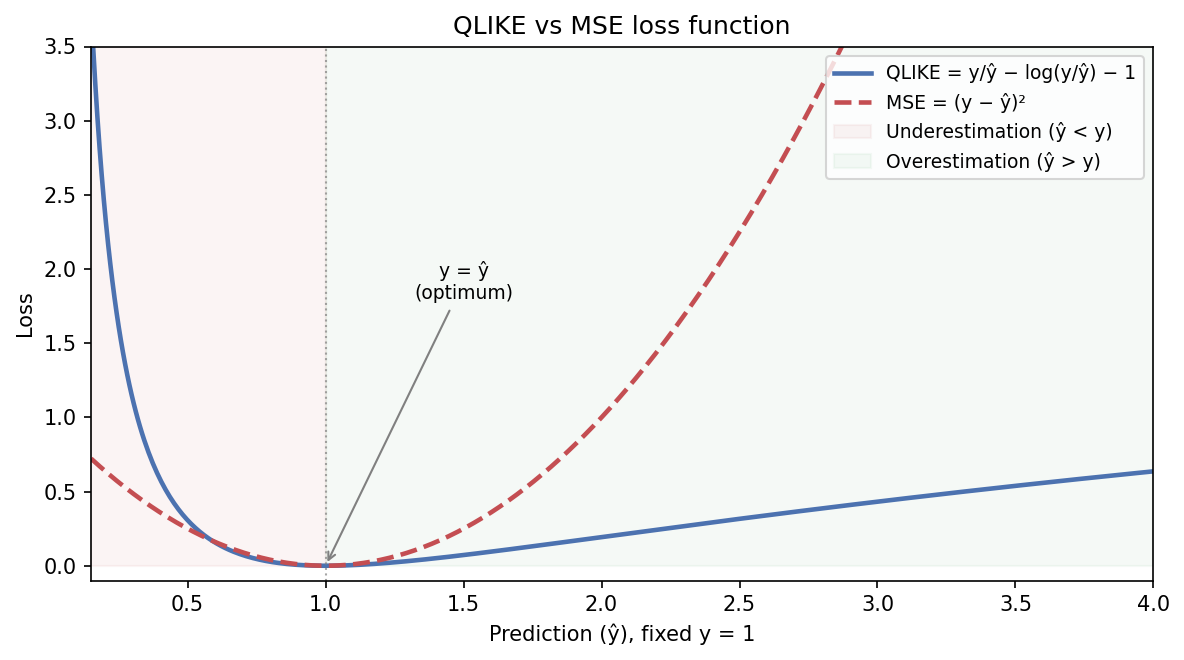

In [3]:
y_true = 1.0  # fix y=1
y_pred = np.linspace(0.15, 4.0, 500)

ratio = y_true / y_pred
qlike = ratio - np.log(ratio) - 1
mse = (y_true - y_pred) ** 2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(y_pred, qlike, color="#4C72B0", lw=2.2, label="QLIKE = y/ŷ − log(y/ŷ) − 1")
ax.plot(y_pred, mse, color="#C44E52", lw=2.2, ls="--", label="MSE = (y − ŷ)²")
ax.axvline(y_true, color="gray", ls=":", lw=1, alpha=0.7)
ax.annotate("y = ŷ\n(optimum)", xy=(y_true, 0), xytext=(1.5, 1.8),
            fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="gray", lw=1))

# Shade asymmetry regions
ax.fill_betweenx([0, 3.5], 0, y_true, alpha=0.06, color="#C44E52", label="Underestimation (ŷ < y)")
ax.fill_betweenx([0, 3.5], y_true, 4, alpha=0.06, color="#55A868", label="Overestimation (ŷ > y)")

ax.set_xlabel("Prediction (ŷ), fixed y = 1")
ax.set_ylabel("Loss")
ax.set_ylim(-0.1, 3.5)
ax.set_xlim(0.15, 4.0)
ax.legend(fontsize=9, loc="upper right")
ax.set_title("QLIKE vs MSE loss function")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_qlike_vs_mse.png", bbox_inches="tight")
plt.show()

## 3. Train / Val / Test temporal split (Section 11)
Sequential 70/10/20 split over the panel's unique trading days. Every symbol on a given day falls into the same set.

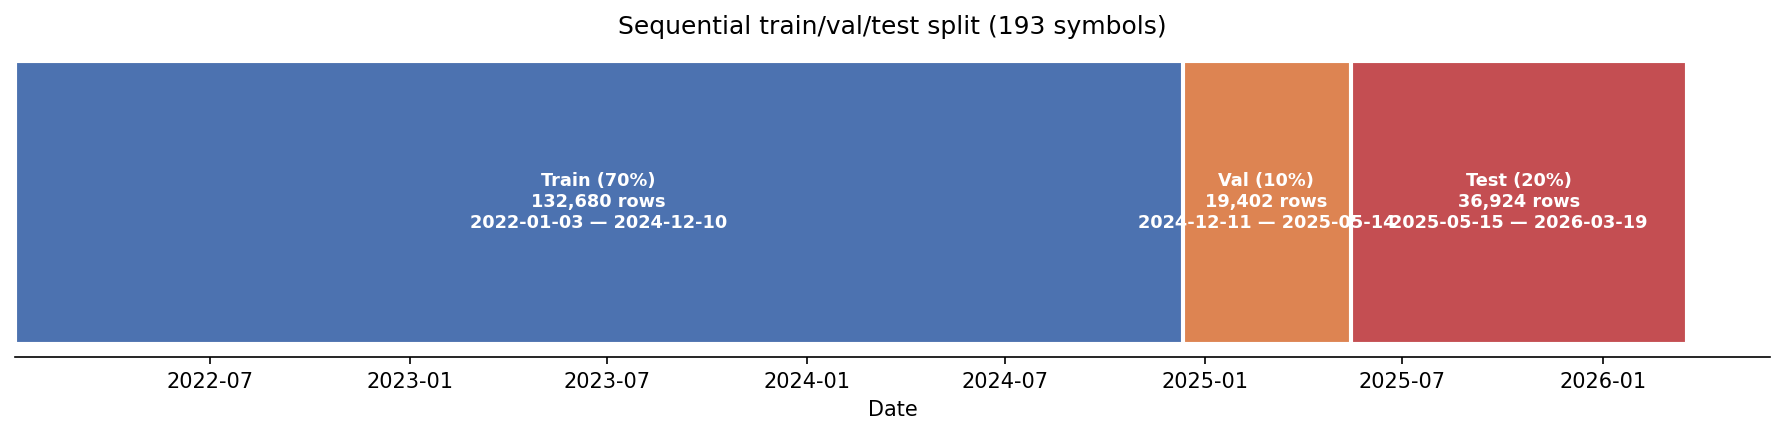

In [4]:
import datetime

# Date ranges & counts
splits_info = [
    ("Train (70%)", train["date"].min(), train["date"].max(), len(train), "#4C72B0"),
    ("Val (10%)",   val["date"].min(),   val["date"].max(),   len(val),   "#DD8452"),
    ("Test (20%)",  test["date"].min(),  test["date"].max(),  len(test),  "#C44E52"),
]

fig, ax = plt.subplots(figsize=(12, 3))

for i, (label, d_min, d_max, n_rows, color) in enumerate(splits_info):
    x0 = d_min.to_pydatetime() if hasattr(d_min, "to_pydatetime") else d_min
    x1 = d_max.to_pydatetime() if hasattr(d_max, "to_pydatetime") else d_max
    ax.barh(0, (x1 - x0).days, left=x0, height=0.5, color=color, edgecolor="white", lw=1.5)
    mid = x0 + (x1 - x0) / 2
    ax.text(mid, 0, f"{label}\n{n_rows:,} rows\n{x0:%Y-%m-%d} — {x1:%Y-%m-%d}",
            ha="center", va="center", fontsize=8.5, fontweight="bold", color="white")

ax.set_yticks([])
ax.set_xlabel("Date")
ax.set_title("Sequential train/val/test split (193 symbols)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig03_train_val_test_split.png", bbox_inches="tight")
plt.show()

## 4. Purged k-fold CV scheme (Section 11)
The most important methodological figure. 5-fold CV with a 21-day embargo (purge) around each fold, Lopez de Prado (2018).

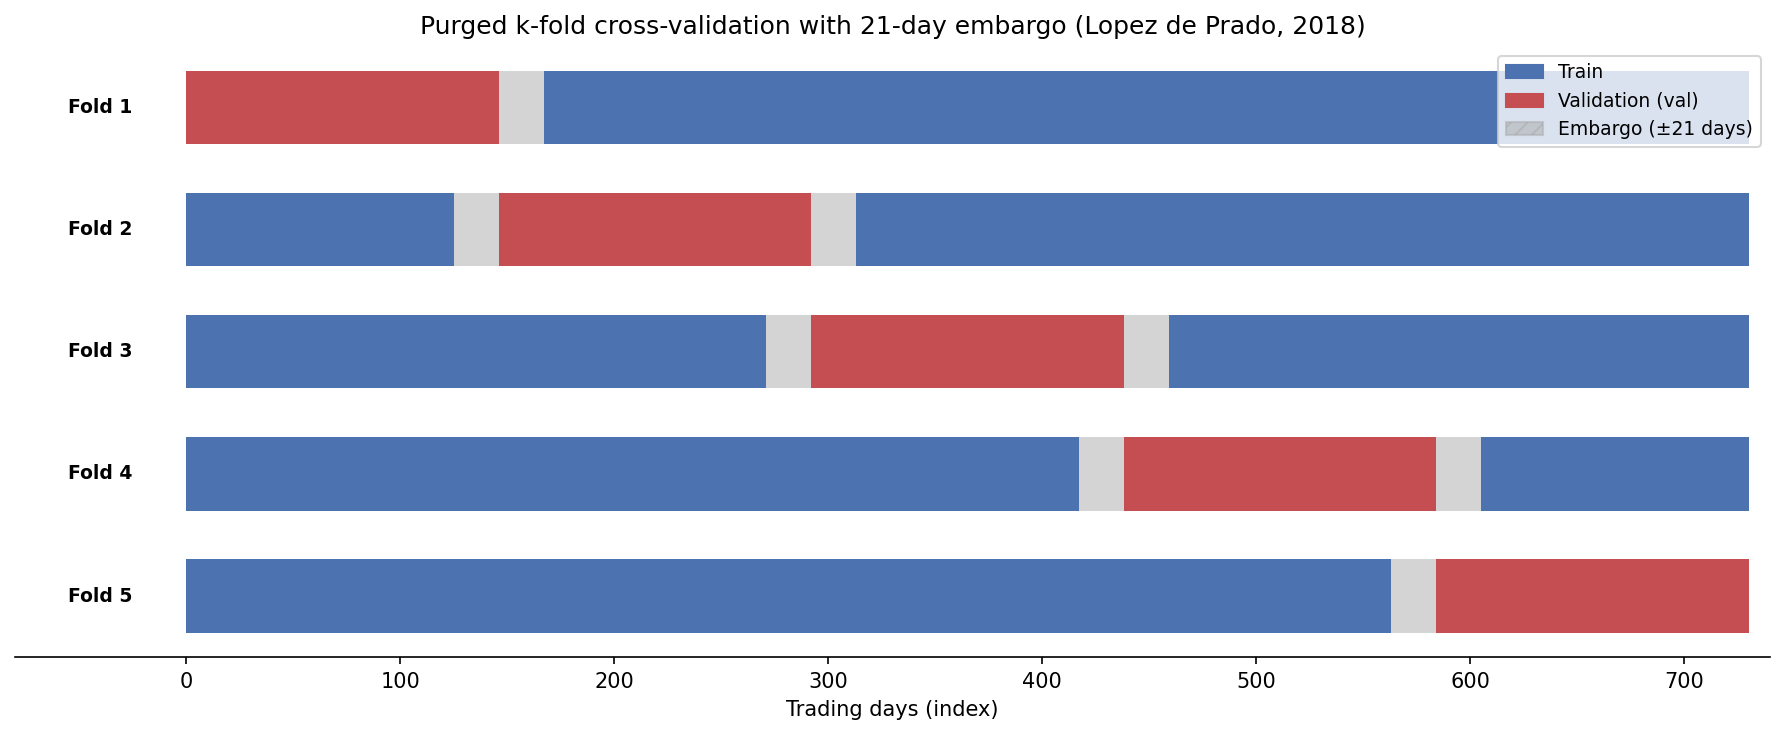

In [5]:
n_splits = 5
embargo = 21
n_dates = 730  # approx training dates
fold_size = n_dates // n_splits

fig, ax = plt.subplots(figsize=(12, 5))

colors = {"Train": "#4C72B0", "Val": "#C44E52", "Embargo": "#AAAAAA"}

for fold_idx in range(n_splits):
    y = n_splits - fold_idx - 1  # top to bottom
    val_start = fold_idx * fold_size
    val_end = val_start + fold_size

    purge_before_start = max(0, val_start - embargo)
    embargo_after_end = min(n_dates, val_end + embargo)

    # Draw train before purge
    if purge_before_start > 0:
        ax.barh(y, purge_before_start, left=0, height=0.6, color=colors["Train"], edgecolor="none")

    # Embargo before val
    if val_start > 0:
        ax.barh(y, val_start - purge_before_start, left=purge_before_start,
                height=0.6, color=colors["Embargo"], edgecolor="none", hatch="///", alpha=0.5)

    # Validation fold
    ax.barh(y, val_end - val_start, left=val_start, height=0.6,
            color=colors["Val"], edgecolor="none")

    # Embargo after val
    ax.barh(y, embargo_after_end - val_end, left=val_end,
            height=0.6, color=colors["Embargo"], edgecolor="none", hatch="///", alpha=0.5)

    # Train after embargo
    if embargo_after_end < n_dates:
        ax.barh(y, n_dates - embargo_after_end, left=embargo_after_end,
                height=0.6, color=colors["Train"], edgecolor="none")

    ax.text(-25, y, f"Fold {fold_idx + 1}", ha="right", va="center", fontsize=9, fontweight="bold")

# Legend
legend_patches = [
    mpatches.Patch(color=colors["Train"], label="Train"),
    mpatches.Patch(color=colors["Val"], label="Validation (val)"),
    mpatches.Patch(color=colors["Embargo"], alpha=0.5, hatch="///", label="Embargo (±21 days)"),
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9)

ax.set_xlabel("Trading days (index)")
ax.set_yticks([])
ax.set_xlim(-80, n_dates + 10)
ax.set_ylim(-0.5, n_splits - 0.5)
ax.set_title("Purged k-fold cross-validation with 21-day embargo (Lopez de Prado, 2018)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig04_purged_kfold.png", bbox_inches="tight")
plt.show()

## 5. FNN architecture (Section 9)
Gu/Kelly/Xiu (2020) NN3: 44 → 32 → 16 → 8 → 1. BatchNorm + ReLU + Dropout after every hidden layer.

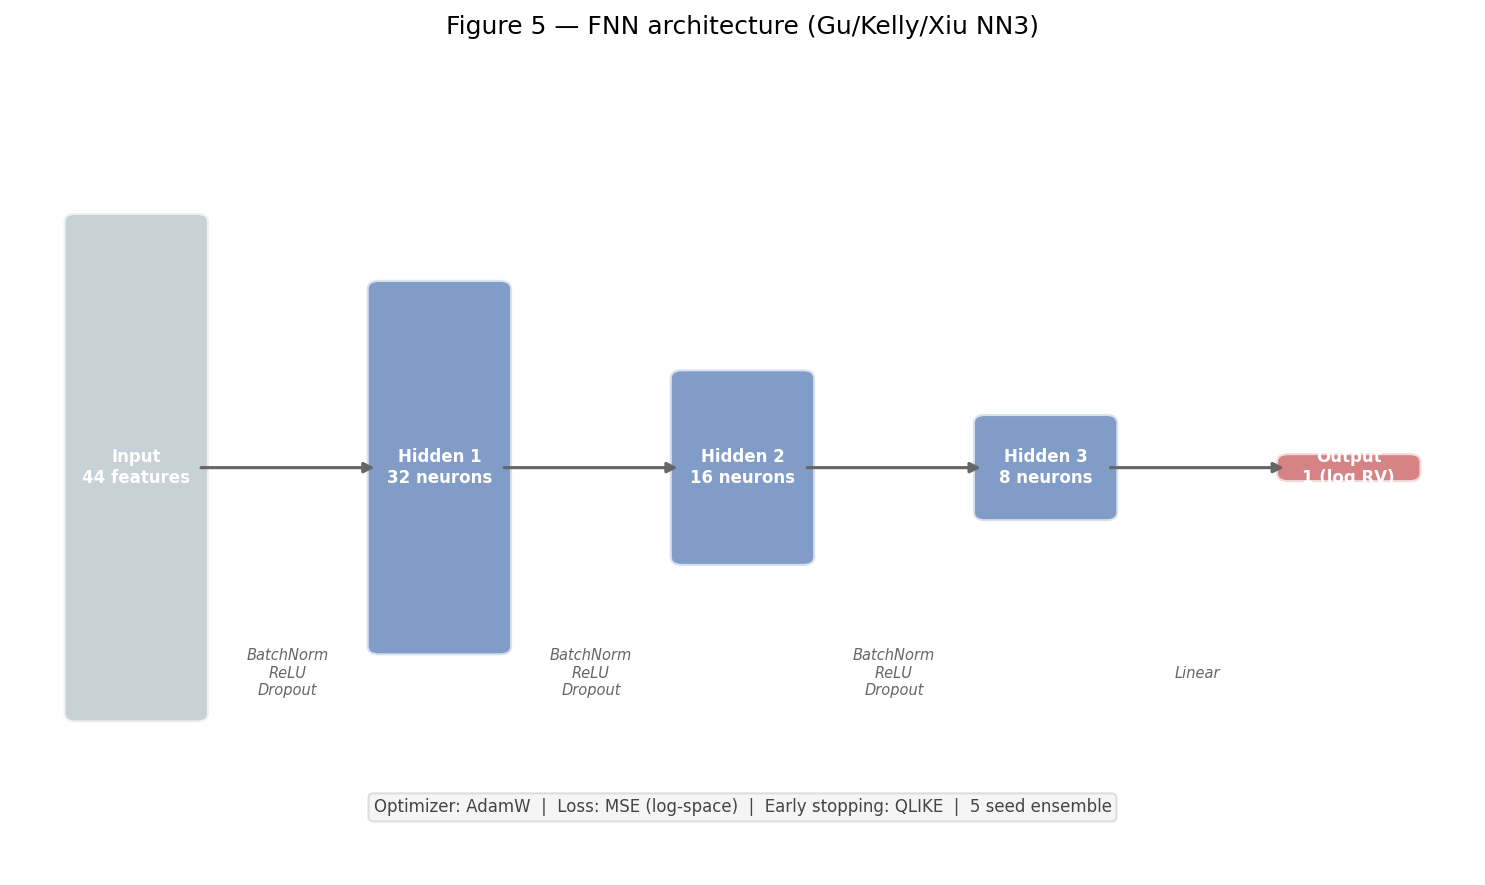

In [6]:
def draw_fnn():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 8)
    ax.axis("off")

    layers = [
        ("Input\n44 features", 44, 0, "#B0BEC5"),
        ("Hidden 1\n32 neurons", 32, 2.5, "#4C72B0"),
        ("Hidden 2\n16 neurons", 16, 5.0, "#4C72B0"),
        ("Hidden 3\n8 neurons", 8, 7.5, "#4C72B0"),
        ("Output\n1 (log RV)", 1, 10.0, "#C44E52"),
    ]

    layer_positions = []
    for label, n_neurons, x, color in layers:
        # Draw layer box
        h = min(n_neurons / 8, 6)
        y_center = 3.5
        rect = FancyBboxPatch((x - 0.5, y_center - h/2), 1.0, h,
                              boxstyle="round,pad=0.1", facecolor=color, alpha=0.7, edgecolor="white", lw=2)
        ax.add_patch(rect)
        ax.text(x, y_center, label, ha="center", va="center", fontsize=8, fontweight="bold", color="white")
        layer_positions.append((x, y_center, h))

    # Arrows between layers
    for i in range(len(layer_positions) - 1):
        x1 = layer_positions[i][0] + 0.5
        x2 = layer_positions[i+1][0] - 0.5
        y = 3.5
        ax.annotate("", xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle="-|>", color="#666", lw=1.5))

        # Label between hidden layers
        if i > 0 and i < len(layer_positions) - 2:
            mid_x = (x1 + x2) / 2
            ax.text(mid_x, 1.2, "BatchNorm\nReLU\nDropout", ha="center", va="center",
                    fontsize=7, color="#666", style="italic")
        elif i == 0:
            mid_x = (x1 + x2) / 2
            ax.text(mid_x, 1.2, "BatchNorm\nReLU\nDropout", ha="center", va="center",
                    fontsize=7, color="#666", style="italic")
        elif i == len(layer_positions) - 2:
            mid_x = (x1 + x2) / 2
            ax.text(mid_x, 1.2, "Linear", ha="center", va="center",
                    fontsize=7, color="#666", style="italic")

    # Training info
    info = "Optimizer: AdamW  |  Loss: MSE (log-space)  |  Early stopping: QLIKE  |  5 seed ensemble"
    ax.text(5, -0.3, info, ha="center", va="center", fontsize=8, color="#444",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#F5F5F5", edgecolor="#DDD"))

    ax.set_title("Figure 5 — FNN architecture (Gu/Kelly/Xiu NN3)", fontsize=12, pad=15)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig05_fnn_architecture.png", bbox_inches="tight")
    plt.show()

draw_fnn()

## 6. LSTM sliding window + architecture (Section 10)
21-day sliding window: (batch, 21, 44) → 2-layer LSTM → Dropout → Linear → 1 (log RV).

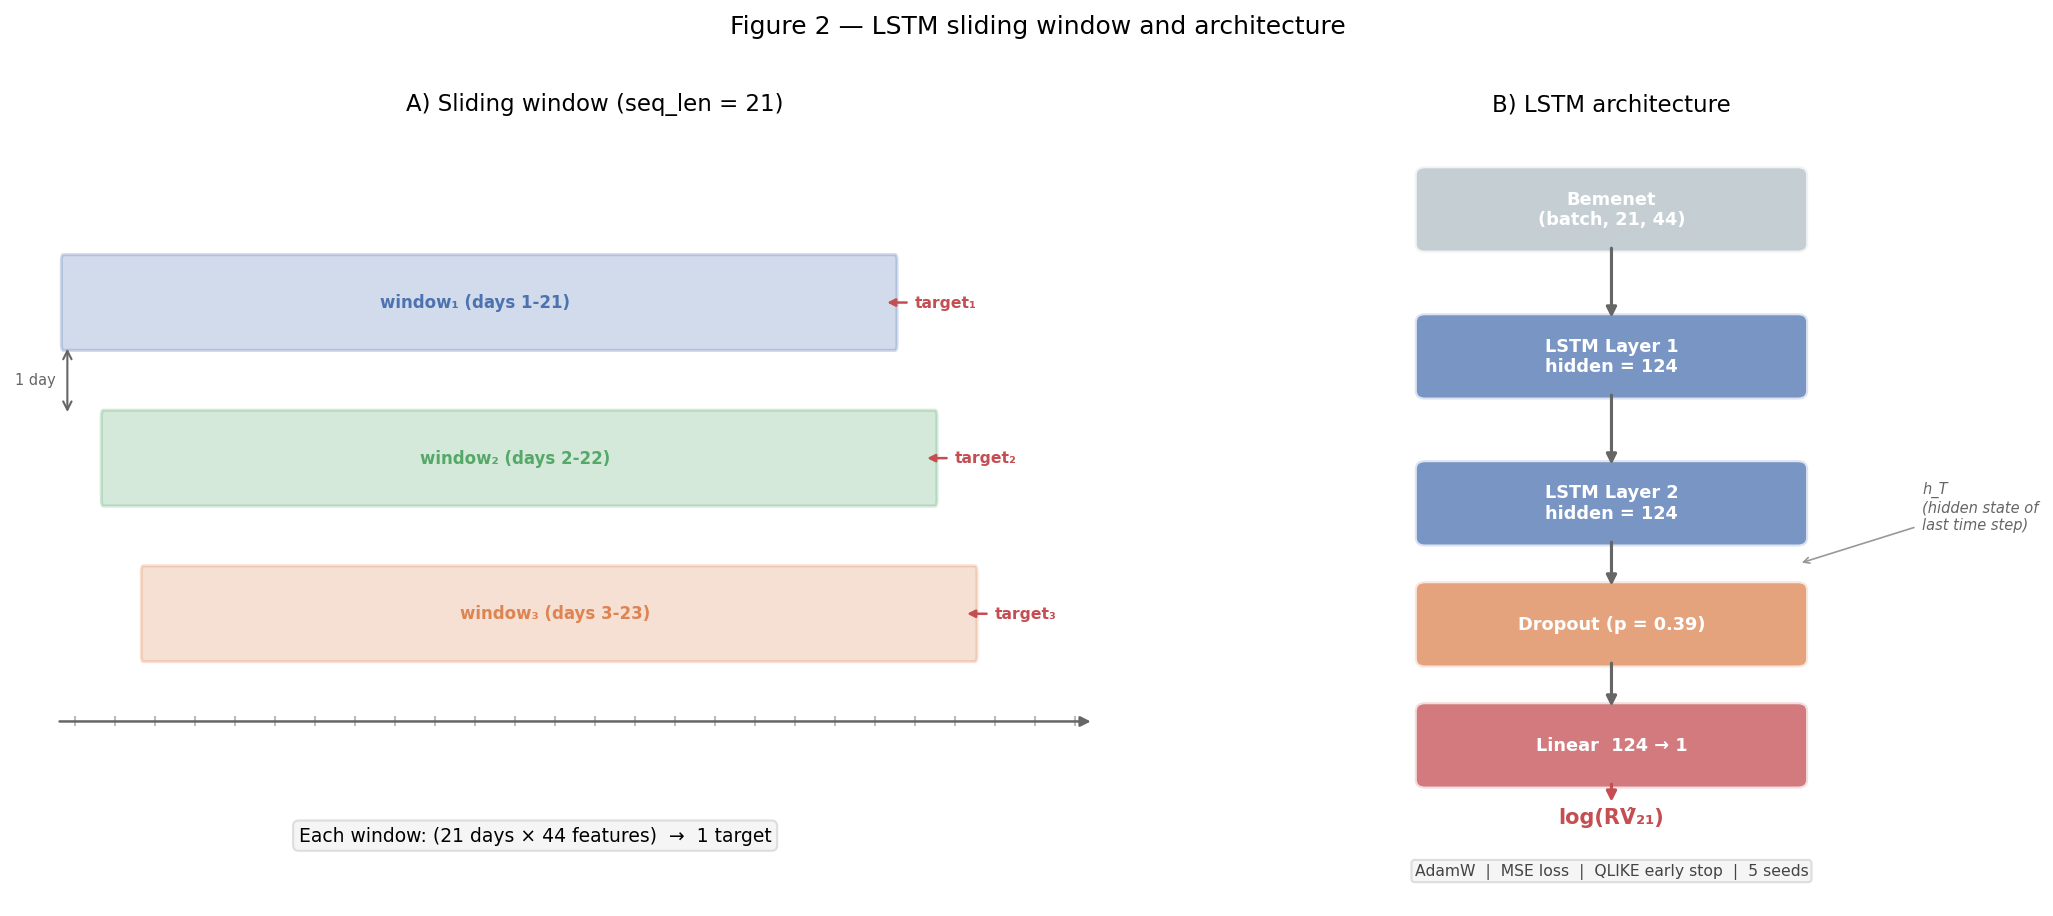

In [7]:
def draw_lstm():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.4, 1]})

    # --- Left panel: Sliding window concept ---
    ax = axes[0]
    ax.set_xlim(-1, 28)
    ax.set_ylim(-1.5, 5)
    ax.axis("off")
    ax.set_title("A) Sliding window (seq_len = 21)", fontsize=11)

    # Time axis at bottom
    ax.annotate("", xy=(26, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="#666", lw=1.2))
    for d in range(26):
        ax.plot(d + 0.5, 0, "|", color="#BBB", ms=5)

    # Draw 3 windows stacked, each shifted by 1 day
    windows = [
        (0, 21, 3.5, "#4C72B0", "window₁ (days 1-21)", 21.5, "target₁"),
        (1, 22, 2.2, "#55A868", "window₂ (days 2-22)", 22.5, "target₂"),
        (2, 23, 0.9, "#DD8452", "window₃ (days 3-23)", 23.5, "target₃"),
    ]
    for start, end, y, color, label, tx, tlabel in windows:
        rect = FancyBboxPatch((start + 0.2, y - 0.35), end - start - 0.2, 0.7,
                              boxstyle="round,pad=0.05", facecolor=color, alpha=0.25,
                              edgecolor=color, lw=1.5)
        ax.add_patch(rect)
        ax.text((start + end) / 2, y, label, ha="center", va="center", fontsize=8, color=color, fontweight="bold")
        # Arrow to target
        ax.annotate(tlabel, xy=(end - 0.3, y), xytext=(tx, y),
                    fontsize=7.5, color="#C44E52", fontweight="bold", va="center",
                    arrowprops=dict(arrowstyle="-|>", color="#C44E52", lw=1.2))

    # Bracket showing "1 day shift"
    ax.annotate("", xy=(0.3, 3.15), xytext=(0.3, 2.55),
                arrowprops=dict(arrowstyle="<->", color="#666", lw=1))
    ax.text(-0.5, 2.85, "1 day", fontsize=7, color="#666", ha="center", va="center")

    # Dimension box
    ax.text(12, -1.0, "Each window: (21 days × 44 features)  →  1 target", ha="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#F5F5F5", edgecolor="#DDD"))

    # --- Right panel: LSTM architecture (top-to-bottom) ---
    ax = axes[1]
    ax.set_xlim(-1, 7)
    ax.set_ylim(-0.5, 8.5)
    ax.axis("off")
    ax.set_title("B) LSTM architecture", fontsize=11)

    # Top-to-bottom: input at top, output at bottom
    blocks = [
        ("Bemenet\n(batch, 21, 44)", 7.5, "#B0BEC5"),
        ("LSTM Layer 1\nhidden = 124", 5.8, "#4C72B0"),
        ("LSTM Layer 2\nhidden = 124", 4.1, "#4C72B0"),
        ("Dropout (p = 0.39)", 2.7, "#DD8452"),
        ("Linear  124 → 1", 1.3, "#C44E52"),
    ]

    x_center = 3.0
    for label, y, color in blocks:
        rect = FancyBboxPatch((x_center - 1.8, y - 0.4), 3.6, 0.8,
                              boxstyle="round,pad=0.1", facecolor=color, alpha=0.75,
                              edgecolor="white", lw=2)
        ax.add_patch(rect)
        ax.text(x_center, y, label, ha="center", va="center", fontsize=8.5, fontweight="bold", color="white")

    # Arrows between blocks (top to bottom)
    for i in range(len(blocks) - 1):
        y_from = blocks[i][1] - 0.4
        y_to = blocks[i + 1][1] + 0.4
        ax.annotate("", xy=(x_center, y_to), xytext=(x_center, y_from),
                    arrowprops=dict(arrowstyle="-|>", color="#666", lw=1.5))

    # h_T annotation between Layer 2 and Dropout
    ax.annotate("h_T\n(hidden state of\nlast time step)", xy=(x_center + 1.8, 3.4),
                xytext=(x_center + 3.0, 3.8),
                fontsize=7, color="#666", style="italic", ha="left",
                arrowprops=dict(arrowstyle="->", color="#999", lw=0.8))

    # Output label
    ax.text(x_center, 0.4, "log(RV̂₂₁)", ha="center", fontsize=10, fontweight="bold", color="#C44E52")
    ax.annotate("", xy=(x_center, 0.6), xytext=(x_center, 0.9),
                arrowprops=dict(arrowstyle="-|>", color="#C44E52", lw=1.5))

    # Training info box at bottom
    ax.text(x_center, -0.2, "AdamW  |  MSE loss  |  QLIKE early stop  |  5 seeds",
            ha="center", fontsize=7.5, color="#444",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#F5F5F5", edgecolor="#DDD"))

    fig.suptitle("Figure 2 — LSTM sliding window and architecture", fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig06_lstm_architecture.png", bbox_inches="tight")
    plt.show()

draw_lstm()